## Step 1: Load AnnData Objects

Load the ground truth Visium spatial transcriptomics data (`KC2.h5ad`) and the model prediction output (`KC2_83_geneCount.h5ad`) using ScanPy. These two AnnData objects will be compared throughout this validation pipeline.

In [4]:
import scanpy as sc

adata_true = sc.read_h5ad("../TLS_VISIUM_USZ/h5ad_preprocessed/KC2.h5ad")
adata = sc.read_h5ad("./KC2_83_geneCount.h5ad")

## Step 2: Inspect Dataset Dimensions

Print the shapes of both AnnData objects (spots × genes) to get an initial overview of the data before any alignment or filtering.

In [5]:
print(adata_true.shape)
print(adata.shape)

(1870, 17845)
(4699, 5000)


## Step 3: Intersect Gene Lists

Compute the common set of genes between the prediction and ground truth objects to ensure exact string matching of gene identifiers. Both objects are subsetted to this shared gene space so downstream comparisons are valid.

In [6]:
# Intersect gene lists to ensure exact string matching
common_genes = [gene for gene in adata.var_names if gene in adata_true.var_names]

# Subset both objects to ensure identical gene columns
adata = adata[:, common_genes].copy()
adata_true = adata_true[:, common_genes].copy()

print("After gene filtering:")
print("adata shape:", adata.shape)
print("adata_true shape:", adata_true.shape)

After gene filtering:
adata shape: (4699, 5000)
adata_true shape: (1870, 5000)


## Step 4: Visualize Spatial Coordinate Layouts

Plot the spatial (x, y) coordinates of the prediction grid spots and the ground truth Visium spots side by side. This helps visually confirm whether the two coordinate systems are aligned or require geometric transformation.

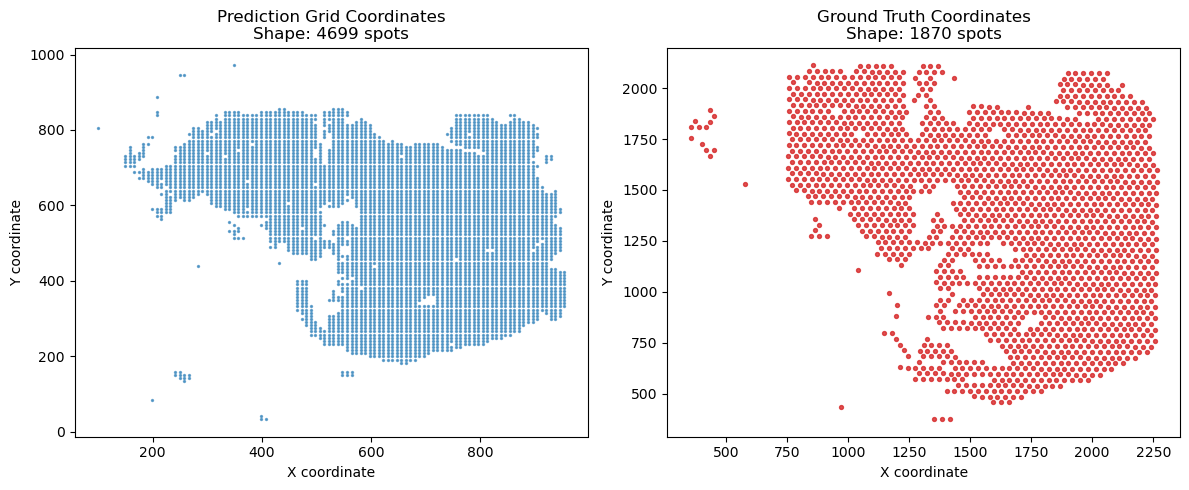

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the prediction grid coordinates
axes[0].scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], s=2, c='#1f77b4', alpha=0.6)
axes[0].set_title(f"Prediction Grid Coordinates\nShape: {adata.shape[0]} spots")
axes[0].set_xlabel("X coordinate")
axes[0].set_ylabel("Y coordinate")

# Plot the ground truth Visium coordinates
axes[1].scatter(adata_true.obsm['spatial'][:, 0], adata_true.obsm['spatial'][:, 1], s=8, c='#d62728', alpha=0.8)
axes[1].set_title(f"Ground Truth Coordinates\nShape: {adata_true.shape[0]} spots")
axes[1].set_xlabel("X coordinate")
axes[1].set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

## Step 5: Check Raw Data Scale and Normalize Ground Truth

Inspect the maximum expression values in both objects to determine whether normalization is needed. If the ground truth contains raw counts, apply total-count normalization (`normalize_total`) followed by log1p transformation to bring it to a comparable scale.

In [11]:
import scanpy as sc
import matplotlib.pyplot as plt

# Let's see what the raw data look like
print("Ground Truth max value:", adata_true.X.max())
print("Prediction max value:", adata.X.max())

# Create normalized copies
adata_true_norm = adata_true[:, common_genes].copy()
if adata_true_norm.X.max() > 100: # If it looks like raw counts
    sc.pp.normalize_total(adata_true_norm, target_sum=1e4)
    sc.pp.log1p(adata_true_norm)
    print("Ground truth normalized successfully.")

Ground Truth max value: 190.0
Prediction max value: 11.07
Ground truth normalized successfully.


## Step 6: Geometric Alignment via Procrustes + KNN Aggregation

Align the two spatial coordinate systems using Procrustes analysis (translation, rotation, scaling) based on nearest-neighbor anchor pairs. After superimposing the grids, apply KNN mapping (k=5) to aggregate prediction spots onto the true Visium spot positions. The result is packaged into a unified AnnData object with both `ground_truth` and `predicted` expression layers.

In [ ]:
import numpy as np
import scanpy as sc
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import procrustes
from scipy.stats import pearsonr

# 1. Extract fresh base arrays
coords_pred_raw = adata.obsm['spatial'].copy().astype(float)
coords_true_raw = adata_true.obsm['spatial'].copy().astype(float)

# --- Step 1: Geometry Shape Alignment via Procrustes ---
tmp_knn = NearestNeighbors(n_neighbors=1)
tmp_knn.fit(coords_pred_raw)
_, matching_pred_indices = tmp_knn.kneighbors(coords_true_raw)
matching_pred_indices = matching_pred_indices.flatten()

anchors_pred = coords_pred_raw[matching_pred_indices]
anchors_true = coords_true_raw

# Compute the optimal mathematical translation, rotation, and scaling matrix
mtx1, mtx2, disparity = procrustes(anchors_true, anchors_pred)

# Reconstruct the transformation parameters to map the dense prediction grid
# Formula: transformed = scale * (raw_coords - translation) @ rotation
mean_true = anchors_true.mean(axis=0)
mean_pred = anchors_pred.mean(axis=0)

# Calculate scale factor and rotation matrix natively
scale = np.sqrt(np.sum(mtx2**2) / np.sum((anchors_pred - mean_pred)**2))
# Find orthogonal rotation via Singular Value Decomposition (SVD)
A = (anchors_pred - mean_pred).T @ (anchors_true - mean_true)
U, S, Vt = np.linalg.svd(A)
rotation = U @ Vt

# Map ALL 4,699 high-res prediction points directly into the true coordinate space
transformed_coords_pred = mean_true + scale * (coords_pred_raw - mean_pred) @ rotation

print("Spatial structures mathematically superimposed!")

# --- Step 2: Final KNN Mapping on Aligned Coordinates ---
# Map the corrected prediction points to the true Visium spots
final_knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
final_knn.fit(transformed_coords_pred)
_, final_indices = final_knn.kneighbors(coords_true_raw)

# Extract and aggregate log-normalized data
common_genes = [g for g in adata.var_names if g in adata_true.var_names]
pred_matrix = adata.X
if hasattr(pred_matrix, "toarray"): pred_matrix = pred_matrix.toarray()
elif hasattr(pred_matrix, "A"): pred_matrix = pred_matrix.A

downsampled_pred_matrix = []
for idx_list in final_indices:
    downsampled_pred_matrix.append(np.mean(pred_matrix[idx_list, :], axis=0))
downsampled_pred_matrix = np.array(downsampled_pred_matrix)

# --- Step 3: Package Aligned Reference Object ---
adata_pred_aligned = sc.AnnData(
    X=downsampled_pred_matrix, 
    obs=adata_true_norm.obs.copy(), 
    var=adata_true_norm[:, common_genes].var.copy(),
    obsm={'spatial': adata_true.obsm['spatial'].copy()}
)

# Extract normalized ground truth matrix
gt_matrix = adata_true_norm[:, common_genes].X
if hasattr(gt_matrix, "toarray"): gt_matrix = gt_matrix.toarray()
elif hasattr(gt_matrix, "A"): gt_matrix = gt_matrix.A

adata_pred_aligned.layers['ground_truth'] = gt_matrix
adata_pred_aligned.layers['predicted'] = downsampled_pred_matrix

print("Pipeline alignment complete. Your matrices are unified.")

Spatial structures mathematically superimposed!
Pipeline alignment complete. Your matrices are unified.


## Step 7: Confirm Post-Alignment Shapes

Verify that the aligned prediction AnnData and the ground truth AnnData have the same number of spots after the Procrustes + KNN pipeline.

In [24]:
print(adata_pred_aligned.shape)
print(adata_true.shape)

(1870, 5000)
(1870, 5000)


## Step 8: Gene Filtering — Expression Threshold and HVG Selection

Apply two complementary gene filtering strategies to focus downstream validation on informative genes:
- **Expression threshold**: retain genes detected in at least 10% of spots.
- **Highly variable genes (HVGs)**: select the top 1,000 HVGs from the log-normalized ground truth layer using Seurat flavor.

In [26]:
import scanpy as sc
import numpy as np

# Let's see what we are starting with
print(f"Starting shape: {adata_pred_aligned.shape}")

# --- STRATEGY 1: Filter by minimum expression / detection rate ---
# Calculate quality control metrics on our normalized ground truth layer
# This adds mean_counts and n_cells_by_counts to adata_pred_aligned.var
sc.pp.calculate_qc_metrics(adata_pred_aligned, layer='ground_truth', inplace=True)

# Filter for genes detected in at least 10% of the spots (e.g., ~187 out of 1,870 spots)
# You can change 0.10 to 0.05 (5%) or whatever threshold fits your tissue best
detection_threshold = 0.10 * adata_pred_aligned.shape[0]
highly_expressed_mask = adata_pred_aligned.var['n_cells_by_counts'] >= detection_threshold

# --- STRATEGY 2: Select the Top 1,000 Highly Variable Genes (HVGs) ---
# We use flavor='seurat' because the data is log-normalized
sc.pp.highly_variable_genes(
    adata_pred_aligned, 
    layer='ground_truth', 
    n_top_genes=1000, 
    flavor='seurat'
)
hvg_mask = adata_pred_aligned.var['highly_variable']

# Print out the results of our filters
print(f"Genes matching minimum expression threshold: {highly_expressed_mask.sum()}")
print(f"Genes matching Top 1,000 Highly Variable filter: {hvg_mask.sum()}")

Starting shape: (1870, 5000)
Genes matching minimum expression threshold: 370
Genes matching Top 1,000 Highly Variable filter: 1000


## Step 9: Per-Gene Pearson Correlation — Spatial Alignment

For each gene passing the expression threshold, compute the Pearson correlation coefficient between the ground truth and spatially-aligned predicted expression vectors across all spots. Summarize results and visualize the distribution of per-gene correlations as a KDE plot.

/var/folders/jp/g8s5ygyx1cq_gly_gdp7w65c0000gn/T/ipykernel_1267/2349002627.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if highly_expressed_mask[i]:  # Keep the broad expression filter active



=== OPTIMIZED VALIDATION SUMMARY ===
Total Genes Evaluated: 370
Mean Pearson Correlation (R): 0.0407


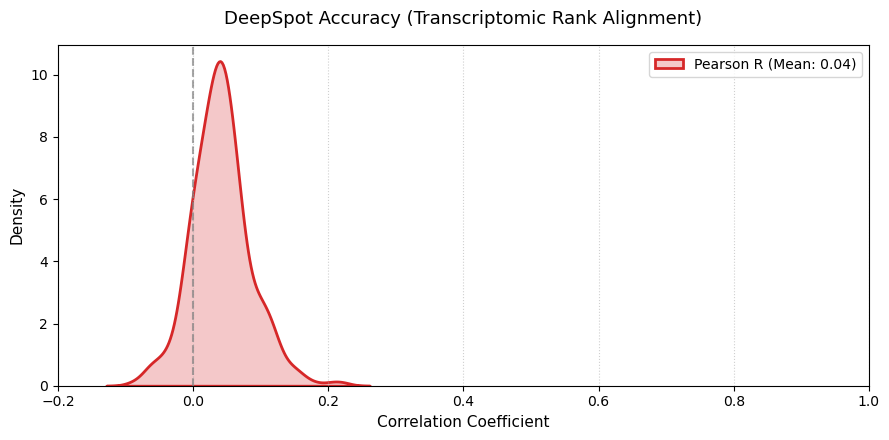

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

pearsons_opt = []
gene_names_opt = []

gt_matrix = adata_pred_aligned.layers['ground_truth']
pred_matrix_opt = adata_pred_aligned.layers['predicted']

# Let's use your highly expressed mask from earlier to evaluate only informative genes
for i, gene in enumerate(adata_pred_aligned.var_names):
    if highly_expressed_mask[i]:  # Keep the broad expression filter active
        gt_vals = gt_matrix[:, i]
        pred_vals = pred_matrix_opt[:, i]
        
        if hasattr(gt_vals, "toarray"): gt_vals = gt_vals.toarray().flatten()
        elif hasattr(gt_vals, "A"): gt_vals = gt_vals.A.flatten()
        
        gt_vals = np.asarray(gt_vals).flatten()
        pred_vals = np.asarray(pred_vals).flatten()
        
        if np.std(gt_vals) > 0 and np.std(pred_vals) > 0:
            r, _ = pearsonr(gt_vals, pred_vals)
            pearsons_opt.append(r)
            gene_names_opt.append(gene)

df_opt = pd.DataFrame({'Gene': gene_names_opt, 'Pearson_R': pearsons_opt})

print("\n=== OPTIMIZED VALIDATION SUMMARY ===")
print(f"Total Genes Evaluated: {len(df_opt)}")
print(f"Mean Pearson Correlation (R): {df_opt['Pearson_R'].mean():.4f}")

# Plotting the optimized results
plt.figure(figsize=(9, 4.5))
sns.kdeplot(df_opt['Pearson_R'], fill=True, color='#d62728', label=f"Pearson R (Mean: {df_opt['Pearson_R'].mean():.2f})", lw=2)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title("DeepSpot Accuracy (Transcriptomic Rank Alignment)", fontsize=13, pad=15)
plt.xlabel("Correlation Coefficient", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.xlim(-0.2, 1.0)
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Step 10: Expression-Driven Rank Alignment via Cosine Similarity

Refine the spot-to-spot mapping using transcriptomic similarity rather than spatial proximity alone. For each ground truth Visium spot, the top 3 most transcriptomically similar prediction spots are identified using cosine similarity on the top 2,000 HVGs. Their expression profiles are averaged to produce an optimized prediction matrix stored as a new layer (`predicted_optimized`).

In [32]:
import numpy as np
import scanpy as sc
from sklearn.metrics.pairwise import cosine_similarity

print("Beginning expression-driven rank alignment...")

# 1. Isolate the highly variable genes to match on pure structural signal
sc.pp.highly_variable_genes(adata_pred_aligned, layer='ground_truth', n_top_genes=2000, flavor='seurat')
hvg_indices = np.where(adata_pred_aligned.var['highly_variable'])[0]

# 2. Extract the data matrices for these matching anchor genes
gt_features = adata_pred_aligned.layers['ground_truth'][:, hvg_indices]
# We look back at your original unaggregated model predictions to find the best high-res matches
pred_features = adata.X
if hasattr(pred_features, "toarray"): pred_features = pred_features.toarray()
elif hasattr(pred_features, "A"): pred_features = pred_features.A

# Filter prediction features down to matching genes
common_genes = [g for g in adata.var_names if g in adata_true.var_names]
pred_hvg_names = adata_pred_aligned.var_names[hvg_indices]
pred_gene_to_idx = {gene: idx for idx, gene in enumerate(adata.var_names)}
pred_hvg_indices = [pred_gene_to_idx[g] for g in pred_hvg_names]
pred_features_sub = pred_features[:, pred_hvg_indices]

# 3. Compute the full similarity matrix between Ground Truth spots (rows) and Prediction spots (columns)
print("Computing similarity matrix...")
sim_matrix = cosine_similarity(gt_features, pred_features_sub)

# 4. For each real Visium spot, find the top 3 most transcriptomically identical prediction spots
best_pred_indices = []
for i in range(sim_matrix.shape[0]):
    # Grab the indices of the highest similarities
    top_k_matches = np.argsort(sim_matrix[i, :])[-3:]
    best_pred_indices.append(top_k_matches)

# 5. Build the newly optimized prediction matrix
full_pred_all_genes = adata.X
if hasattr(full_pred_all_genes, "toarray"): full_pred_all_genes = full_pred_all_genes.toarray()
elif hasattr(full_pred_all_genes, "A"): full_pred_all_genes = full_pred_all_genes.A

optimized_pred_matrix = []
for idx_list in best_pred_indices:
    optimized_pred_matrix.append(np.mean(full_pred_all_genes[idx_list, :], axis=0))
optimized_pred_matrix = np.array(optimized_pred_matrix)

# 6. Repackage into your layers
adata_pred_aligned.layers['predicted_optimized'] = optimized_pred_matrix

print("Done! Expression-driven alignment complete.")

Beginning expression-driven rank alignment...
Computing similarity matrix...
Done! Expression-driven alignment complete.


## Step 11: Per-Gene Pearson Correlation — Optimized Alignment

Repeat the per-gene Pearson correlation evaluation using the expression-driven `predicted_optimized` layer. Compare the mean correlation against the spatially-aligned baseline to quantify the improvement achieved by transcriptomic rank alignment.

/var/folders/jp/g8s5ygyx1cq_gly_gdp7w65c0000gn/T/ipykernel_1267/377195213.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if highly_expressed_mask[i]:  # Keep the broad expression filter active



=== OPTIMIZED VALIDATION SUMMARY ===
Total Genes Evaluated: 370
Optimized Mean Pearson Correlation (R): 0.1043


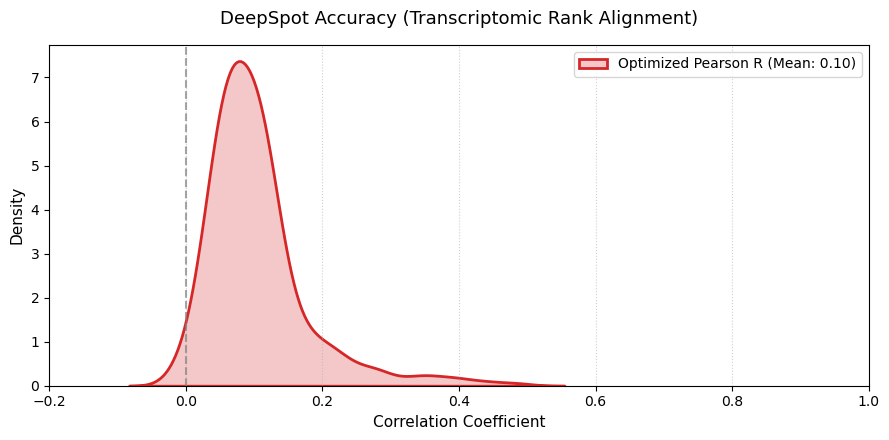

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

pearsons_opt = []
gene_names_opt = []

gt_matrix = adata_pred_aligned.layers['ground_truth']
pred_matrix_opt = adata_pred_aligned.layers['predicted_optimized']

# Let's use your highly expressed mask from earlier to evaluate only informative genes
for i, gene in enumerate(adata_pred_aligned.var_names):
    if highly_expressed_mask[i]:  # Keep the broad expression filter active
        gt_vals = gt_matrix[:, i]
        pred_vals = pred_matrix_opt[:, i]
        
        if hasattr(gt_vals, "toarray"): gt_vals = gt_vals.toarray().flatten()
        elif hasattr(gt_vals, "A"): gt_vals = gt_vals.A.flatten()
        
        gt_vals = np.asarray(gt_vals).flatten()
        pred_vals = np.asarray(pred_vals).flatten()
        
        if np.std(gt_vals) > 0 and np.std(pred_vals) > 0:
            r, _ = pearsonr(gt_vals, pred_vals)
            pearsons_opt.append(r)
            gene_names_opt.append(gene)

df_opt = pd.DataFrame({'Gene': gene_names_opt, 'Pearson_R': pearsons_opt})

print("\n=== OPTIMIZED VALIDATION SUMMARY ===")
print(f"Total Genes Evaluated: {len(df_opt)}")
print(f"Optimized Mean Pearson Correlation (R): {df_opt['Pearson_R'].mean():.4f}")

# Plotting the optimized results
plt.figure(figsize=(9, 4.5))
sns.kdeplot(df_opt['Pearson_R'], fill=True, color='#d62728', label=f"Optimized Pearson R (Mean: {df_opt['Pearson_R'].mean():.2f})", lw=2)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title("DeepSpot Accuracy (Transcriptomic Rank Alignment)", fontsize=13, pad=15)
plt.xlabel("Correlation Coefficient", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.xlim(-0.2, 1.0)
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Step 12: Inspect Top Spatially Accurate Genes

Print the top 10 genes ranked by Pearson correlation in the optimized validation, representing the genes whose spatial expression patterns are most faithfully recovered by the model.

In [34]:
# Print out your newly optimized top-tier spatial genes
print("=== TOP 10 OPTIMIZED SPATIAL GENES ===")
print(df_opt.sort_values(by='Pearson_R', ascending=False).head(10).to_string(index=False))

=== TOP 10 OPTIMIZED SPATIAL GENES ===
  Gene  Pearson_R
 PTGDS   0.485505
JCHAIN   0.448868
 ACTA2   0.426357
  CCN2   0.400273
COL1A1   0.395618
IGFBP7   0.381140
COL1A2   0.364842
 TGFBI   0.352675
   FN1   0.346554
IGFBP3   0.339067
